Updated neural operator model for quantification of losses and plots

In [1]:
import os
import glob
import numpy as np
import torch
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader

from neuralop.models import FNO
from neuralop import Trainer
from neuralop.training import AdamW
from neuralop.losses import LpLoss
from neuralop.utils import count_model_params

device = "cpu"

In [2]:
from pathlib import Path

cwd = Path.cwd().resolve()
if (cwd / "data" / "train").exists():
    BASE_DIR = cwd
elif (cwd.parent / "data" / "train").exists():
    BASE_DIR = cwd.parent
else:
    raise FileNotFoundError("Could not locate repo root containing data/train")
TRAIN_ROOT = BASE_DIR / "data" / "train"

SIM_DIRS = [
    os.path.join(TRAIN_ROOT, "pair_1_grid_2D"),
    os.path.join(TRAIN_ROOT, "pair_2_grid_2D"),
]

for d in SIM_DIRS:
    assert os.path.isdir(d), f"Missing directory: {d}"


def split_simulation_frames(sim_dir, train_frac=0.8):
    files = sorted(
        glob.glob(os.path.join(sim_dir, "frame_*_grid.npz")),
        key=lambda f: int(os.path.basename(f).split("_")[1])
    )

    n_total = len(files)
    n_train = int(train_frac * n_total)

    train_files = files[:n_train]
    test_files  = files[n_train:]

    return train_files, test_files


train_files = []
test_files  = []

for sim_dir in SIM_DIRS:
    tr, te = split_simulation_frames(sim_dir, train_frac=0.8)
    train_files.extend(tr)
    test_files.extend(te)

print("===================================")
print(f"Simulations used   : {len(SIM_DIRS)}")
print(f"Train samples     : {len(train_files)}")
print(f"Test samples      : {len(test_files)}")
print("===================================")

assert len(train_files) > 0
assert len(test_files) > 0

Simulations used   : 2
Train samples     : 44
Test samples      : 12


In [3]:
EXPECTED_RES = 32

def assert_expected_resolution(files, expected_res):
    bad = []
    for f in files:
        d = np.load(f)
        x_shape = tuple(d["input_grid"].shape)
        y_shape = tuple(d["U_grid"].shape)
        ok = (
            len(x_shape) == 3 and len(y_shape) == 3
            and x_shape[0] == 3 and y_shape[0] == 2
            and x_shape[1:] == (expected_res, expected_res)
            and y_shape[1:] == (expected_res, expected_res)
        )
        if not ok:
            bad.append((f, x_shape, y_shape))
            if len(bad) >= 5:
                break
    if bad:
        msg = "\n".join([f"{fp} -> x:{xs}, y:{ys}" for fp, xs, ys in bad])
        raise RuntimeError(
            f"Found non-{expected_res}x{expected_res} samples. Regenerate grids first.\nExamples:\n{msg}"
        )

assert_expected_resolution(train_files + test_files, EXPECTED_RES)

class VPMGridDataset(Dataset):
    """
    Operator dataset: a(x,y) -> u(x,y)
    input_grid : (3, 32, 32)
    U_grid     : (2, 32, 32)
    """

    def __init__(self, files):
        self.files = files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = np.load(self.files[idx])
        x = torch.tensor(data["input_grid"], dtype=torch.float32)
        y = torch.tensor(data["U_grid"], dtype=torch.float32)
        assert tuple(x.shape) == (3, EXPECTED_RES, EXPECTED_RES), f"Bad x shape: {x.shape}"
        assert tuple(y.shape) == (2, EXPECTED_RES, EXPECTED_RES), f"Bad y shape: {y.shape}"
        return {"x": x, "y": y}

train_dataset = VPMGridDataset(train_files)
test_dataset  = VPMGridDataset(test_files)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)

test_loaders = {EXPECTED_RES: test_loader}
print(f"Using fixed training resolution: {EXPECTED_RES}x{EXPECTED_RES}")


Using fixed training resolution: 32x32


In [4]:
model = FNO(
    n_modes=(20, 20),
    in_channels=3,
    out_channels=2,
    hidden_channels=64,
    projection_channel_ratio=4,
).to(device)

print(model)
print("Total parameters:", count_model_params(model))


optimizer = AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=120
)

l2loss = LpLoss(d=2, p=2)


FNO(
  (positional_embedding): GridEmbeddingND()
  (fno_blocks): FNOBlocks(
    (convs): ModuleList(
      (0-3): 4 x SpectralConv(
        (weight): DenseTensor(shape=torch.Size([64, 64, 20, 11]), rank=None)
      )
    )
    (fno_skips): ModuleList(
      (0-3): 4 x Flattened1dConv(
        (conv): Conv1d(64, 64, kernel_size=(1,), stride=(1,), bias=False)
      )
    )
    (channel_mlp): ModuleList(
      (0-3): 4 x ChannelMLP(
        (fcs): ModuleList(
          (0): Conv1d(64, 32, kernel_size=(1,), stride=(1,))
          (1): Conv1d(32, 64, kernel_size=(1,), stride=(1,))
        )
      )
    )
    (channel_mlp_skips): ModuleList(
      (0-3): 4 x SoftGating()
    )
  )
  (lifting): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(5, 128, kernel_size=(1,), stride=(1,))
      (1): Conv1d(128, 64, kernel_size=(1,), stride=(1,))
    )
  )
  (projection): ChannelMLP(
    (fcs): ModuleList(
      (0): Conv1d(64, 256, kernel_size=(1,), stride=(1,))
      (1): Conv1d(256, 2, kernel_s

In [5]:
# Rebuild loaders in-cell to avoid stale notebook objects
train_dataset = VPMGridDataset(train_files)
test_dataset  = VPMGridDataset(test_files)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    drop_last=(len(train_dataset) >= 2),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
)
test_loaders = {EXPECTED_RES: test_loader}

def _loader_shapes(loader, n_batches=3):
    shapes = set()
    for i, batch in enumerate(loader):
        x = batch["x"]
        y = batch["y"]
        shapes.add((tuple(x.shape), tuple(y.shape)))
        if i + 1 >= n_batches:
            break
    return shapes

shape_preview = _loader_shapes(train_loader, n_batches=3)
print("Train batch shape preview:", shape_preview)
expected_batch_shape = (2, 3, EXPECTED_RES, EXPECTED_RES)
assert all(s[0][1:] == expected_batch_shape[1:] and s[1][1:] == (2, EXPECTED_RES, EXPECTED_RES) for s in shape_preview), shape_preview

trainer = Trainer(
    model=model,
    n_epochs=120,
    device=device,
    data_processor=None,
    wandb_log=False,
    eval_interval=5,
    verbose=True,
)

trainer.train(
    train_loader=train_loader,
    test_loaders=test_loaders,
    optimizer=optimizer,
    scheduler=scheduler,
    training_loss=l2loss,
    eval_losses={"l2": l2loss},
)


Train batch shape preview: {((2, 3, 32, 32), (2, 2, 32, 32))}
Training on 44 samples
Testing on [12] samples         on resolutions [32].
Raw outputs of shape torch.Size([2, 2, 32, 32])


/home/dysco/Neeraj/Flow-reconstruction-in-VPM-using-FNO/neuralop-env/lib/python3.10/site-packages/torch/nn/modules/module.py:1786: UserWarning: FNO.forward() received unexpected keyword arguments: ['y']. These arguments will be ignored.
  return forward_call(*args, **kwargs)
/home/dysco/Neeraj/Flow-reconstruction-in-VPM-using-FNO/neuralop-env/lib/python3.10/site-packages/neuralop/training/trainer.py:536: UserWarning: LpLoss.__call__() received unexpected keyword arguments: ['x']. These arguments will be ignored.
  loss += training_loss(out, **sample)


[0] time=3.46, avg_loss=92.7038, train_err=185.4075
Eval: 32_l2=92.1829
[5] time=2.61, avg_loss=4.0174, train_err=8.0348
Eval: 32_l2=10.7227
[10] time=2.45, avg_loss=1.2688, train_err=2.5377
Eval: 32_l2=1.3709
[15] time=2.32, avg_loss=1.0238, train_err=2.0477
Eval: 32_l2=1.0708
[20] time=2.48, avg_loss=0.5816, train_err=1.1633
Eval: 32_l2=0.6844
[25] time=2.39, avg_loss=0.3345, train_err=0.6691
Eval: 32_l2=0.6142
[30] time=2.47, avg_loss=0.5093, train_err=1.0185
Eval: 32_l2=0.8072
[35] time=2.57, avg_loss=0.3642, train_err=0.7285
Eval: 32_l2=0.5855
[40] time=3.24, avg_loss=0.3776, train_err=0.7552
Eval: 32_l2=0.6765
[45] time=2.63, avg_loss=0.4977, train_err=0.9954
Eval: 32_l2=0.6513
[50] time=2.48, avg_loss=0.3086, train_err=0.6172
Eval: 32_l2=0.7120
[55] time=2.97, avg_loss=0.2179, train_err=0.4358
Eval: 32_l2=0.5511
[60] time=3.50, avg_loss=0.2126, train_err=0.4252
Eval: 32_l2=0.6513
[65] time=2.53, avg_loss=0.1356, train_err=0.2712
Eval: 32_l2=0.5554
[70] time=2.50, avg_loss=0.1978

{'train_err': 0.1089509500359947,
 'avg_loss': 0.05447547501799735,
 'avg_lasso_loss': None,
 'epoch_train_time': 2.4343525069998577}

In [6]:
model.eval()

sample = test_dataset[0]
x = sample["x"].unsqueeze(0).to(device)
y_true = sample["y"]

with torch.no_grad():
    y_pred = model(x)[0].cpu()

speed_true = torch.sqrt(y_true[0]**2 + y_true[1]**2)
speed_pred = torch.sqrt(y_pred[0]**2 + y_pred[1]**2)
error = torch.norm(y_pred - y_true, dim=0)

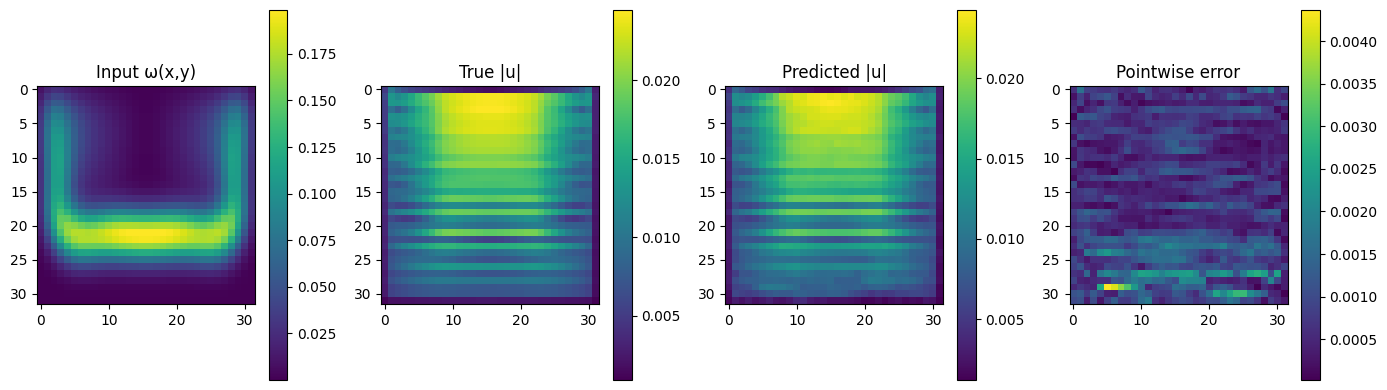

In [7]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(x[0, 0].cpu())
plt.title("Input ω(x,y)")
plt.colorbar()

plt.subplot(1, 4, 2)
plt.imshow(speed_true)
plt.title("True |u|")
plt.colorbar()

plt.subplot(1, 4, 3)
plt.imshow(speed_pred)
plt.title("Predicted |u|")
plt.colorbar()

plt.subplot(1, 4, 4)
plt.imshow(error)
plt.title("Pointwise error")
plt.colorbar()

plt.tight_layout()
plt.show()

## Enhanced Training And Evaluation (Codex)

This section keeps your original notebook content and adds a stronger, configurable training/evaluation flow with extra metrics, convergence plots, parameter diagnostics, and an optional sweep utility.


In [8]:
# Enhanced imports + config
import glob
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

from neuralop.models import FNO
from neuralop.losses import LpLoss
from neuralop.utils import count_model_params

ENH_CFG = {
    "seed": 42,
    "split_mode": "chronological",  # "chronological" or "random"
    "train_frac": 0.8,
    "batch_size": 4,
    "epochs": 120,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "n_modes": (12, 12),
    "hidden_channels": 64,
    "projection_channel_ratio": 4,
    "eval_every": 1,
    "grid_res": 32,
    "input_channels": 1,
    "input_key": "input_grid_omega",
}

def enh_set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

enh_set_seed(ENH_CFG["seed"])
ENH_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Enhanced device:", ENH_DEVICE)


Enhanced device: cpu


In [9]:
# Enhanced data setup
cwd = Path.cwd().resolve()
if (cwd / "data" / "train").exists():
    ENH_REPO_ROOT = cwd
elif (cwd.parent / "data" / "train").exists():
    ENH_REPO_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not locate repo root containing data/train")

ENH_RESULTS_DIR = ENH_REPO_ROOT / "results"
ENH_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Saving plots to: {ENH_RESULTS_DIR}")

def enh_save_fig(fig, filename, dpi=200):
    out_path = ENH_RESULTS_DIR / filename
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
    print(f"[saved] {out_path}")

ENH_TRAIN_ROOT = ENH_REPO_ROOT / "data" / "train"
ENH_SIM_DIRS = [
    ENH_TRAIN_ROOT / "pair_1_grid_2D",
    ENH_TRAIN_ROOT / "pair_2_grid_2D",
]
for d in ENH_SIM_DIRS:
    assert d.is_dir(), f"Missing directory: {d}"

ENH_EXPECTED_RES = int(ENH_CFG["grid_res"])

def enh_split_simulation_frames(sim_dir, train_frac=0.8, mode="chronological", seed=42):
    files = sorted(
        glob.glob(str(sim_dir / "frame_*_grid.npz")),
        key=lambda f: int(Path(f).stem.split("_")[1]),
    )
    n_total = len(files)
    assert n_total > 1, f"Not enough files in {sim_dir}"

    if mode == "random":
        rng = np.random.default_rng(seed)
        idx = np.arange(n_total)
        rng.shuffle(idx)
        files = [files[i] for i in idx]
    elif mode != "chronological":
        raise ValueError("split mode must be 'chronological' or 'random'")

    n_train = max(1, int(train_frac * n_total))
    n_train = min(n_train, n_total - 1)
    return files[:n_train], files[n_train:]

ENH_TRAIN_FILES, ENH_VAL_FILES = [], []
for i, sim_dir in enumerate(ENH_SIM_DIRS):
    tr, va = enh_split_simulation_frames(
        sim_dir,
        train_frac=ENH_CFG["train_frac"],
        mode=ENH_CFG["split_mode"],
        seed=ENH_CFG["seed"] + i,
    )
    ENH_TRAIN_FILES.extend(tr)
    ENH_VAL_FILES.extend(va)

print(f"Enhanced split -> train: {len(ENH_TRAIN_FILES)}, val: {len(ENH_VAL_FILES)}")

def enh_load_input_from_npz(data):
    key = ENH_CFG["input_key"]
    if key not in data:
        raise KeyError(f"Missing key '{key}' in npz. Available keys: {data.files}")

    x = np.asarray(data[key], dtype=np.float32)
    if x.ndim == 2:
        x = x[None, :, :]
    return x

def enh_assert_expected_shapes(files, expected_res, expected_channels):
    bad = []
    for f in files:
        d = np.load(f)
        x = enh_load_input_from_npz(d)
        y = np.asarray(d["U_grid"], dtype=np.float32)

        ok = (
            tuple(x.shape) == (expected_channels, expected_res, expected_res)
            and tuple(y.shape) == (2, expected_res, expected_res)
        )
        if not ok:
            bad.append((f, tuple(x.shape), tuple(y.shape)))
            if len(bad) >= 5:
                break

    if bad:
        msg = "\n".join([f"{fp} -> x:{xs}, y:{ys}" for fp, xs, ys in bad])
        raise RuntimeError(
            f"Found bad sample shapes for key={ENH_CFG['input_key']}\nExamples:\n{msg}"
        )

enh_assert_expected_shapes(
    ENH_TRAIN_FILES + ENH_VAL_FILES,
    expected_res=ENH_EXPECTED_RES,
    expected_channels=int(ENH_CFG["input_channels"]),
)

class ENH_VPMGridDataset(Dataset):
    def __init__(self, files):
        self.files = files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        d = np.load(self.files[idx])
        x = torch.tensor(enh_load_input_from_npz(d), dtype=torch.float32)
        y = torch.tensor(np.asarray(d["U_grid"], dtype=np.float32), dtype=torch.float32)
        return x, y

ENH_TRAIN_DS = ENH_VPMGridDataset(ENH_TRAIN_FILES)
ENH_VAL_DS = ENH_VPMGridDataset(ENH_VAL_FILES)

enh_drop_last = len(ENH_TRAIN_DS) >= ENH_CFG["batch_size"]
ENH_TRAIN_LOADER = DataLoader(
    ENH_TRAIN_DS,
    batch_size=ENH_CFG["batch_size"],
    shuffle=True,
    drop_last=enh_drop_last,
)
ENH_VAL_LOADER = DataLoader(
    ENH_VAL_DS,
    batch_size=ENH_CFG["batch_size"],
    shuffle=False,
)

enh_x0, enh_y0 = ENH_TRAIN_DS[0]
print("Enhanced sample shapes:", tuple(enh_x0.shape), tuple(enh_y0.shape))
print("Enhanced input key:", ENH_CFG["input_key"])


Saving plots to: /home/dysco/Neeraj/Flow-reconstruction-in-VPM-using-FNO/results
Enhanced split -> train: 44, val: 12
Enhanced domain x:[-2.24000, 10.24000] y:[-4.16000, 4.16000]
Enhanced sample shapes: (1, 32, 32) (2, 32, 32)
Enhanced input channels: 1


In [10]:
# Enhanced model + metrics
ENH_MODEL = FNO(
    n_modes=ENH_CFG["n_modes"],
    in_channels=ENH_CFG["input_channels"],
    out_channels=2,
    hidden_channels=ENH_CFG["hidden_channels"],
    projection_channel_ratio=ENH_CFG["projection_channel_ratio"],
).to(ENH_DEVICE)

enh_total_params = count_model_params(ENH_MODEL)
enh_trainable_params = sum(p.numel() for p in ENH_MODEL.parameters() if p.requires_grad)
print("Enhanced total params:", enh_total_params)
print("Enhanced trainable params:", enh_trainable_params)

ENH_OPTIMIZER = torch.optim.AdamW(
    ENH_MODEL.parameters(),
    lr=ENH_CFG["lr"],
    weight_decay=ENH_CFG["weight_decay"],
)
ENH_SCHEDULER = torch.optim.lr_scheduler.CosineAnnealingLR(
    ENH_OPTIMIZER,
    T_max=ENH_CFG["epochs"],
)
ENH_LOSS_FN = LpLoss(d=2, p=2)

def enh_batch_metrics(pred, target):
    diff = pred - target
    mse = torch.mean(diff ** 2, dim=(1, 2, 3))
    mae = torch.mean(torch.abs(diff), dim=(1, 2, 3))
    rmse = torch.sqrt(mse)

    diff_flat = diff.reshape(diff.shape[0], -1)
    tgt_flat = target.reshape(target.shape[0], -1)
    rel_l2 = torch.linalg.norm(diff_flat, dim=1) / torch.linalg.norm(tgt_flat, dim=1).clamp_min(1e-12)

    return {
        "mse": mse.mean().item(),
        "mae": mae.mean().item(),
        "rmse": rmse.mean().item(),
        "rel_l2": rel_l2.mean().item(),
    }

@torch.no_grad()
def enh_evaluate(model, loader, device):
    model.eval()
    accum = {"mse": 0.0, "mae": 0.0, "rmse": 0.0, "rel_l2": 0.0}
    n_batches = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x)
        m = enh_batch_metrics(pred, y)
        for k in accum:
            accum[k] += m[k]
        n_batches += 1

    for k in accum:
        accum[k] /= max(n_batches, 1)
    return accum


Enhanced total params: 2812098
Enhanced trainable params: 1435842


In [11]:
# Enhanced training loop + history
ENH_HISTORY = {
    "epoch": [],
    "train_lp": [],
    "val_rel_l2": [],
    "val_rmse": [],
    "val_mae": [],
    "val_mse": [],
    "lr": [],
}

for epoch in range(1, ENH_CFG["epochs"] + 1):
    ENH_MODEL.train()
    running_train_lp = 0.0
    nb = 0

    for x, y in ENH_TRAIN_LOADER:
        x, y = x.to(ENH_DEVICE), y.to(ENH_DEVICE)
        ENH_OPTIMIZER.zero_grad(set_to_none=True)
        pred = ENH_MODEL(x)
        loss = ENH_LOSS_FN(pred, y)
        loss.backward()
        ENH_OPTIMIZER.step()
        running_train_lp += loss.item()
        nb += 1

    ENH_SCHEDULER.step()
    train_lp = running_train_lp / max(nb, 1)

    if epoch % ENH_CFG["eval_every"] == 0:
        val_m = enh_evaluate(ENH_MODEL, ENH_VAL_LOADER, ENH_DEVICE)
        ENH_HISTORY["epoch"].append(epoch)
        ENH_HISTORY["train_lp"].append(train_lp)
        ENH_HISTORY["val_rel_l2"].append(val_m["rel_l2"])
        ENH_HISTORY["val_rmse"].append(val_m["rmse"])
        ENH_HISTORY["val_mae"].append(val_m["mae"])
        ENH_HISTORY["val_mse"].append(val_m["mse"])
        ENH_HISTORY["lr"].append(ENH_OPTIMIZER.param_groups[0]["lr"])

        print(
            f"[{epoch:03d}] train_lp={train_lp:.4e} "
            f"val_rel_l2={val_m['rel_l2']:.4e} "
            f"val_rmse={val_m['rmse']:.4e} "
            f"val_mae={val_m['mae']:.4e} "
            f"val_mse={val_m['mse']:.4e} "
            f"lr={ENH_HISTORY['lr'][-1]:.2e}"
        )


[001] train_lp=5.7925e+01 val_rel_l2=3.9866e+00 val_rmse=1.6866e-02 val_mae=1.4236e-02 val_mse=3.2469e-04 lr=1.00e-03
[002] train_lp=2.6995e+01 val_rel_l2=1.6233e+00 val_rmse=8.1247e-03 val_mae=5.8994e-03 val_mse=9.7376e-05 lr=9.99e-04
[003] train_lp=1.2885e+01 val_rel_l2=1.8440e+00 val_rmse=8.4133e-03 val_mae=5.5037e-03 val_mse=8.9900e-05 lr=9.98e-04
[004] train_lp=1.2010e+01 val_rel_l2=1.0414e+00 val_rmse=7.4479e-03 val_mae=3.5862e-03 val_mse=1.3113e-04 lr=9.97e-04
[005] train_lp=9.9482e+00 val_rel_l2=9.0511e-01 val_rmse=6.4686e-03 val_mae=3.0773e-03 val_mse=9.8335e-05 lr=9.96e-04
[006] train_lp=8.4451e+00 val_rel_l2=7.5420e-01 val_rmse=4.5500e-03 val_mae=2.5511e-03 val_mse=3.8949e-05 lr=9.94e-04
[007] train_lp=6.9669e+00 val_rel_l2=1.0307e+00 val_rmse=5.3418e-03 val_mae=3.5493e-03 val_mse=4.3531e-05 lr=9.92e-04
[008] train_lp=9.1824e+00 val_rel_l2=1.3085e+00 val_rmse=5.7950e-03 val_mae=4.7101e-03 val_mse=4.0703e-05 lr=9.89e-04
[009] train_lp=8.4951e+00 val_rel_l2=8.6614e-01 val_rmse

[saved] /home/dysco/Neeraj/Flow-reconstruction-in-VPM-using-FNO/results/enh_params_by_module.png


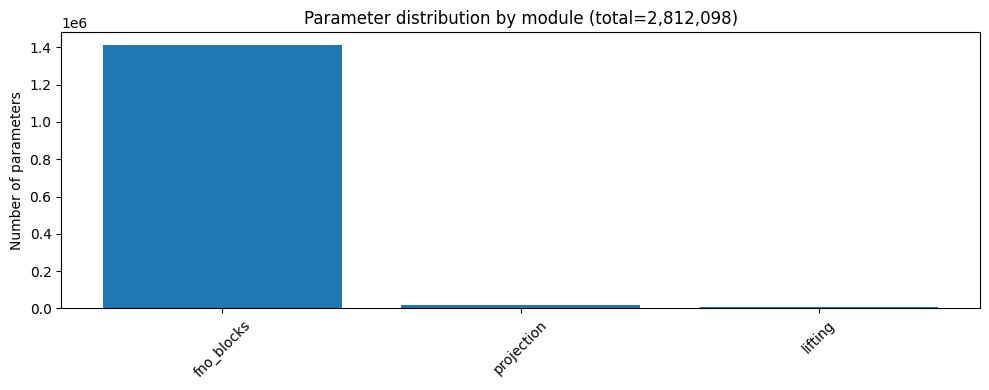

[saved] /home/dysco/Neeraj/Flow-reconstruction-in-VPM-using-FNO/results/enh_convergence_metrics.png


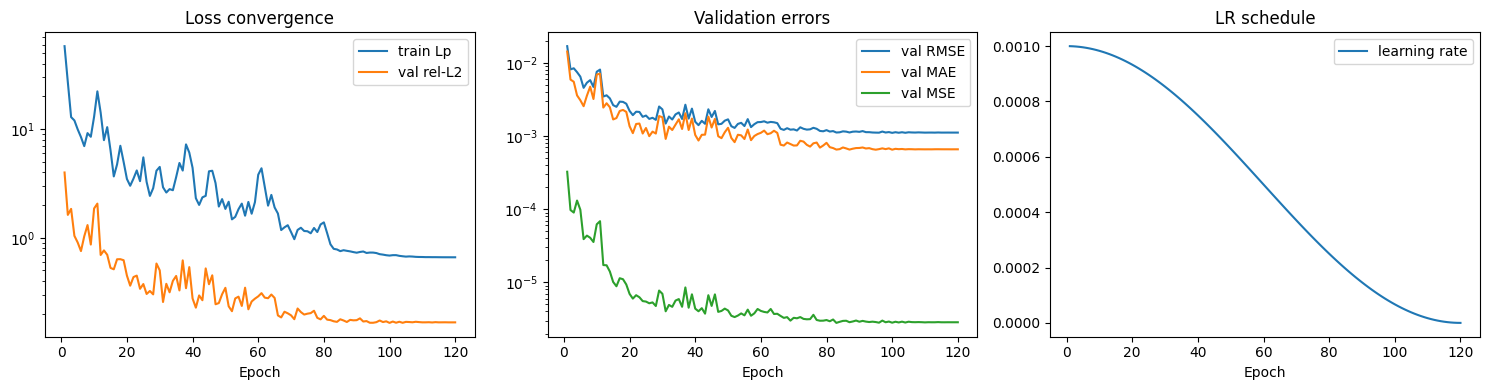

[saved] /home/dysco/Neeraj/Flow-reconstruction-in-VPM-using-FNO/results/enh_qualitative_sample.png


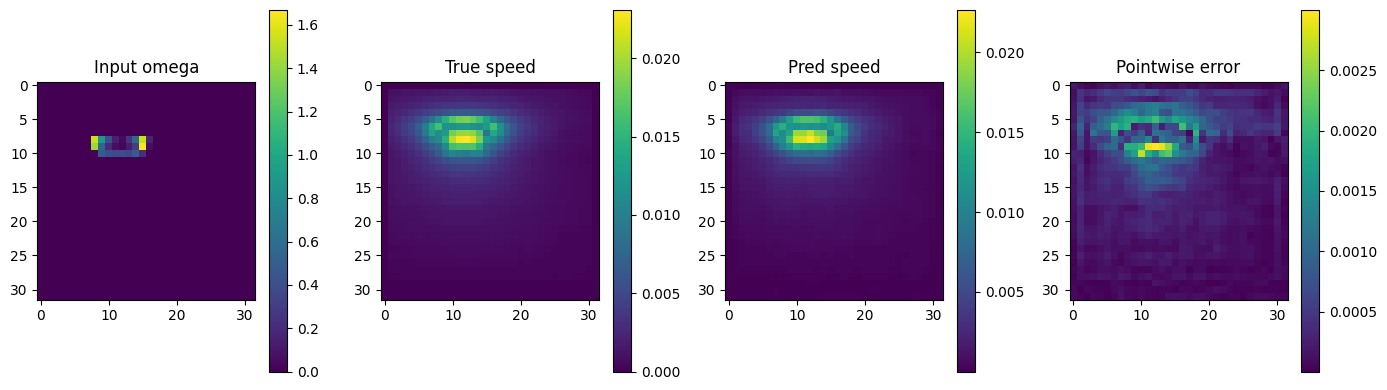

In [12]:
# Enhanced plots: parameter diagnostics + convergence + qualitative result
module_param_counts = defaultdict(int)
for name, p in ENH_MODEL.named_parameters():
    module_name = name.split(".")[0]
    module_param_counts[module_name] += p.numel()

mods = list(module_param_counts.keys())
vals = [module_param_counts[m] for m in mods]
order = np.argsort(vals)[::-1]
mods = [mods[i] for i in order]
vals = [vals[i] for i in order]

fig_params, ax_params = plt.subplots(figsize=(10, 4))
ax_params.bar(mods, vals)
ax_params.set_title(f"Parameter distribution by module (total={enh_total_params:,})")
ax_params.set_ylabel("Number of parameters")
ax_params.tick_params(axis="x", rotation=45)
fig_params.tight_layout()
enh_save_fig(fig_params, "enh_params_by_module.png")
plt.show()

fig_conv, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].plot(ENH_HISTORY["epoch"], ENH_HISTORY["train_lp"], label="train Lp")
axs[0].plot(ENH_HISTORY["epoch"], ENH_HISTORY["val_rel_l2"], label="val rel-L2")
axs[0].set_yscale("log")
axs[0].set_xlabel("Epoch")
axs[0].set_title("Loss convergence")
axs[0].legend()

axs[1].plot(ENH_HISTORY["epoch"], ENH_HISTORY["val_rmse"], label="val RMSE")
axs[1].plot(ENH_HISTORY["epoch"], ENH_HISTORY["val_mae"], label="val MAE")
axs[1].plot(ENH_HISTORY["epoch"], ENH_HISTORY["val_mse"], label="val MSE")
axs[1].set_yscale("log")
axs[1].set_xlabel("Epoch")
axs[1].set_title("Validation errors")
axs[1].legend()

axs[2].plot(ENH_HISTORY["epoch"], ENH_HISTORY["lr"], label="learning rate")
axs[2].set_xlabel("Epoch")
axs[2].set_title("LR schedule")
axs[2].legend()

fig_conv.tight_layout()
enh_save_fig(fig_conv, "enh_convergence_metrics.png")
plt.show()

ENH_MODEL.eval()
enh_xs, enh_ys = ENH_VAL_DS[0]
with torch.no_grad():
    enh_yp = ENH_MODEL(enh_xs.unsqueeze(0).to(ENH_DEVICE))[0].cpu()

enh_speed_true = torch.sqrt(enh_ys[0] ** 2 + enh_ys[1] ** 2)
enh_speed_pred = torch.sqrt(enh_yp[0] ** 2 + enh_yp[1] ** 2)
enh_err_map = torch.norm(enh_yp - enh_ys, dim=0)

fig_qual = plt.figure(figsize=(14, 4))
plt.subplot(1, 4, 1); plt.imshow(enh_xs[0]); plt.title("Input omega"); plt.colorbar()
plt.subplot(1, 4, 2); plt.imshow(enh_speed_true); plt.title("True speed")
plt.colorbar()
plt.subplot(1, 4, 3); plt.imshow(enh_speed_pred); plt.title("Pred speed")
plt.colorbar()
plt.subplot(1, 4, 4); plt.imshow(enh_err_map); plt.title("Pointwise error")
plt.colorbar()
fig_qual.tight_layout()
enh_save_fig(fig_qual, "enh_qualitative_sample.png")
plt.show()


In [13]:
# Optional quick sweep utility for convergence sensitivity
def enh_quick_sweep(param_name, values, base_cfg, quick_epochs=8):
    results = []
    for v in values:
        cfg = dict(base_cfg)
        cfg[param_name] = v
        cfg["epochs"] = quick_epochs

        enh_set_seed(cfg["seed"])
        m = FNO(
            n_modes=cfg["n_modes"],
            in_channels=cfg["input_channels"],
            out_channels=2,
            hidden_channels=cfg["hidden_channels"],
            projection_channel_ratio=cfg["projection_channel_ratio"],
        ).to(ENH_DEVICE)
        opt = torch.optim.AdamW(m.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg["epochs"])
        loss_fn = LpLoss(d=2, p=2)

        for _ in range(cfg["epochs"]):
            m.train()
            for x, y in ENH_TRAIN_LOADER:
                x, y = x.to(ENH_DEVICE), y.to(ENH_DEVICE)
                opt.zero_grad(set_to_none=True)
                pred = m(x)
                loss = loss_fn(pred, y)
                loss.backward()
                opt.step()
            sch.step()

        val_m = enh_evaluate(m, ENH_VAL_LOADER, ENH_DEVICE)
        results.append((v, val_m["rel_l2"]))

    xs = [r[0] for r in results]
    ys = [r[1] for r in results]
    plt.figure(figsize=(6, 4))
    plt.plot(xs, ys, marker="o")
    plt.xlabel(param_name)
    plt.ylabel("Final val rel-L2")
    plt.title(f"Quick sweep: {param_name}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return results

# Example:
# enh_quick_sweep("hidden_channels", [32, 48, 64, 96], ENH_CFG, quick_epochs=8)


## Chronological Error Visualizations (Codex)

Adds explicit relative-error convergence plotting and snapshot panels over chronological validation frames (true vs prediction vs pointwise error).


[saved] /home/dysco/Neeraj/Flow-reconstruction-in-VPM-using-FNO/results/enh_relative_error_vs_epoch.png


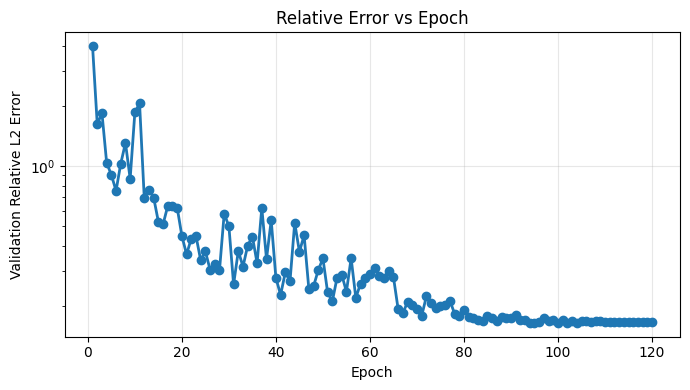

In [14]:
# Explicit relative error vs epoch plot
if len(ENH_HISTORY["epoch"]) == 0:
    raise RuntimeError("ENH_HISTORY is empty. Run the enhanced training cell first.")

fig_rel, ax_rel = plt.subplots(figsize=(7, 4))
ax_rel.plot(ENH_HISTORY["epoch"], ENH_HISTORY["val_rel_l2"], marker="o", linewidth=2)
ax_rel.set_yscale("log")
ax_rel.set_xlabel("Epoch")
ax_rel.set_ylabel("Validation Relative L2 Error")
ax_rel.set_title("Relative Error vs Epoch")
ax_rel.grid(True, alpha=0.3)
fig_rel.tight_layout()
enh_save_fig(fig_rel, "enh_relative_error_vs_epoch.png")
plt.show()


[saved] /home/dysco/Neeraj/Flow-reconstruction-in-VPM-using-FNO/results/enh_chronological_snapshots_pair_1.png


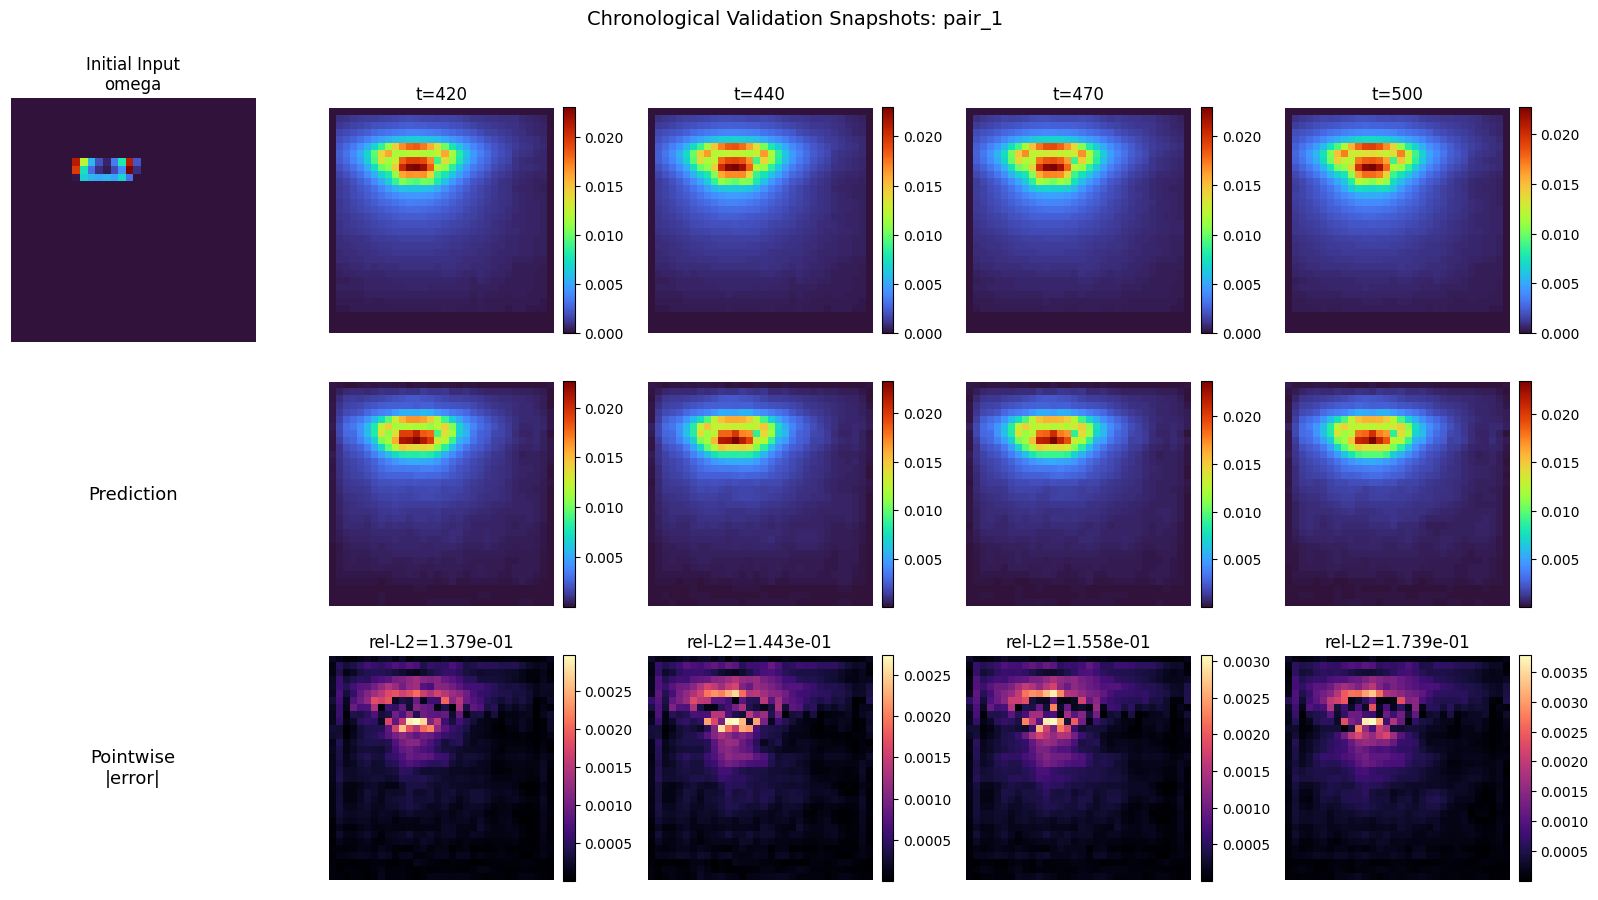

[saved] /home/dysco/Neeraj/Flow-reconstruction-in-VPM-using-FNO/results/enh_chronological_snapshots_pair_2.png


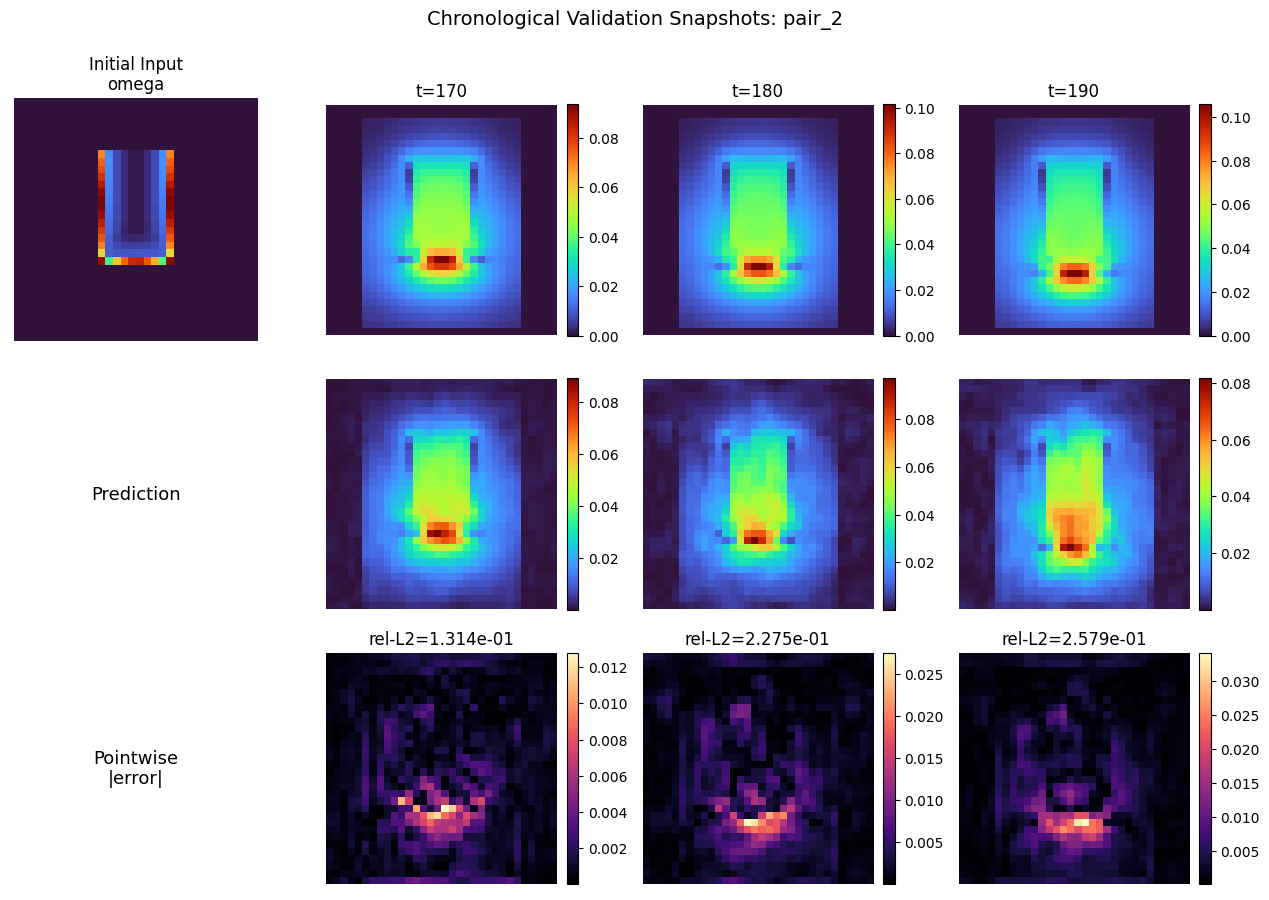

In [15]:
# Chronological snapshot panel: true/prediction/pointwise error
from pathlib import Path

def enh_frame_id(path_like):
    stem = Path(path_like).stem  # frame_150_grid
    return int(stem.split("_")[1])

def enh_load_xy(file_path):
    d = np.load(file_path)
    x = torch.tensor(enh_load_input_from_npz(d), dtype=torch.float32)
    y = torch.tensor(np.asarray(d["U_grid"], dtype=np.float32), dtype=torch.float32)
    return x, y

def plot_chronological_snapshots(sim_name="pair_1_grid_2D", n_times=4):
    files = [f for f in ENH_VAL_FILES if f"/{sim_name}/" in str(f)]
    if len(files) == 0:
        raise RuntimeError(f"No validation files found for {sim_name}")

    files = sorted(files, key=enh_frame_id)
    n_times = max(1, min(n_times, len(files)))
    idxs = np.linspace(0, len(files) - 1, n_times, dtype=int)
    chosen = [files[i] for i in idxs]

    init_x, _ = enh_load_xy(files[0])

    ENH_MODEL.eval()
    true_fields, pred_fields, err_fields = [], [], []
    rel_errors, frame_ids = [], []

    with torch.no_grad():
        for f in chosen:
            x, y = enh_load_xy(f)
            pred = ENH_MODEL(x.unsqueeze(0).to(ENH_DEVICE))[0].cpu()

            speed_true = torch.sqrt(y[0] ** 2 + y[1] ** 2)
            speed_pred = torch.sqrt(pred[0] ** 2 + pred[1] ** 2)
            point_err = torch.abs(speed_pred - speed_true)

            rel = (
                torch.linalg.norm((pred - y).reshape(-1))
                / torch.linalg.norm(y.reshape(-1)).clamp_min(1e-12)
            ).item()

            true_fields.append(speed_true)
            pred_fields.append(speed_pred)
            err_fields.append(point_err)
            rel_errors.append(rel)
            frame_ids.append(enh_frame_id(f))

    ncols = 1 + len(chosen)
    fig, axs = plt.subplots(3, ncols, figsize=(3.2 * ncols, 9))

    axs[0, 0].imshow(init_x[0], cmap="turbo")
    axs[0, 0].set_title("Initial Input")
    axs[0, 0].axis("off")
    axs[1, 0].axis("off")
    axs[1, 0].text(0.5, 0.5, "Prediction", ha="center", va="center", fontsize=13)
    axs[2, 0].axis("off")
    axs[2, 0].text(0.5, 0.5, "Pointwise\n|error|", ha="center", va="center", fontsize=13)

    for j, (fid, t_field, p_field, e_field, rel) in enumerate(
        zip(frame_ids, true_fields, pred_fields, err_fields, rel_errors), start=1
    ):
        im0 = axs[0, j].imshow(t_field, cmap="turbo")
        axs[0, j].set_title(f"t={fid}")
        axs[0, j].axis("off")
        plt.colorbar(im0, ax=axs[0, j], fraction=0.046, pad=0.04)

        im1 = axs[1, j].imshow(p_field, cmap="turbo")
        axs[1, j].axis("off")
        plt.colorbar(im1, ax=axs[1, j], fraction=0.046, pad=0.04)

        im2 = axs[2, j].imshow(e_field, cmap="magma")
        axs[2, j].set_title(f"rel-L2={rel:.3e}")
        axs[2, j].axis("off")
        plt.colorbar(im2, ax=axs[2, j], fraction=0.046, pad=0.04)

    fig.suptitle(f"Chronological Validation Snapshots: {sim_name}", fontsize=14, y=0.995)
    fig.tight_layout()
    safe_sim = sim_name.replace("/", "_").replace(" ", "_")
    enh_save_fig(fig, f"enh_chronological_snapshots_{safe_sim}.png")
    plt.show()

# Run for each simulation present in validation split
plot_chronological_snapshots(sim_name="pair_1_grid_2D", n_times=4)
plot_chronological_snapshots(sim_name="pair_2_grid_2D", n_times=4)
